# Learning to See in the Dark — **Improved**
**Based on:** Chen et al., CVPR 2018 | Reference: susiejojo/Seeing-in-the-Dark  
**Course:** Foundation of Computer Vision  
**Authors:** Talha Asim (22K-4589) | Umer Ahmed (22K-4599) | Laiba Tabraiz

---

Lost kaggle runtime to complete 200 iters


## Cell 1 — Install & Imports

In [1]:
import subprocess, sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rawpy', '-q'])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-image', '-q'])

import os, re, glob, random, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import rawpy
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.models as models

from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}')
print(f'Device : {DEVICE}' + (f'  ({torch.cuda.get_device_name(0)})' if torch.cuda.is_available() else ''))

PyTorch 2.10.0+cu128
Device : cuda  (Tesla T4)


## Cell 2 — Configuration

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Configuration  (full replacement)
# New vs original:
#   - NUM_EPOCHS 100 → 200
#   - LR_FINAL   1e-5 → 1e-6
#   - SSIM_TARGET / two-phase loss weights / PSNR-phase LR / eval cadence
#   - RESUME_CKPT lets you point at any checkpoint file
# ══════════════════════════════════════════════════════════════════════════════
 
import os
import torch
 
# ── Paths ─────────────────────────────────────────────────────────────────────
INPUT_DIR      = '/kaggle/input/datasets/moodoki/sid-sony'
SONY_SHORT_DIR = os.path.join(INPUT_DIR, 'Sony/short')
SONY_LONG_DIR  = os.path.join(INPUT_DIR, 'Sony/long')
TRAIN_LIST     = os.path.join(INPUT_DIR, 'Sony_train_list.txt')
TEST_LIST      = os.path.join(INPUT_DIR, 'Sony_test_list.txt')
 
OUTPUT_DIR = '/kaggle/working/outputs'
CKPT_DIR   = '/kaggle/working/checkpoints'
VIS_DIR    = '/kaggle/working/visualizations'
CACHE_DIR  = '/kaggle/working/cache'
for d in [OUTPUT_DIR, CKPT_DIR, VIS_DIR, CACHE_DIR]:
    os.makedirs(d, exist_ok=True)
 
# ── Training ──────────────────────────────────────────────────────────────────

NUM_EPOCHS       = 200          # ← was 100; need room for PSNR phase
LR_INIT          = 3e-4
LR_FINAL         = 1e-6         # ← was 1e-5; finer late convergence
SAVE_EVERY       = 25
EVAL_EVERY       = 5            # SSIM phase cadence
EVAL_EVERY_PSNR  = 2            # ← tighter evals once PSNR phase starts
NUM_EVAL_SAMPLES = 30

PATCH_SIZE       = 256   # was 512 — quarters GT tensor size per sample
BATCH_SIZE       = 4     # was 8 — halves VRAM per step, allows more pairs
ACCUM_STEPS      = 2     # was 4 — was compensating for small batch; now correct
NUM_WORKERS      = 2     # was 4 — you only have 2 cores, 4 causes thrashing

MAX_TRAIN_PAIRS  = 400
MAX_TEST_PAIRS   = 200
MAX_CACHE_GB     = 20
 
# ── Model ─────────────────────────────────────────────────────────────────────
BASE_CHANNELS    = 32
UNET_DEPTH       = 5
 
# ── Loss — SSIM phase (default) ───────────────────────────────────────────────
USE_PERCEPTUAL    = True
PERCEPTUAL_WEIGHT = 0.04
SSIM_WEIGHT       = 0.02
MSE_WEIGHT        = 0.0         # off during SSIM phase
 
# ── Loss — PSNR phase (activated automatically once SSIM ≥ target) ────────────
SSIM_TARGET              = 0.70   # threshold that triggers phase switch
PERCEPTUAL_WEIGHT_PSNR   = 0.01   # ← sharply reduced (perceptual smooths pixels)
SSIM_WEIGHT_PSNR         = 0.0    # ← off (stop pulling gradients away from MSE)
MSE_WEIGHT_PSNR          = 1.0    # ← ON; PSNR = 10·log10(1/MSE)
EDGE_WEIGHT_PSNR         = 0.1    # ← sharpness recovery
LR_PSNR_PHASE            = 5e-5   # LR reset when phase switches
 
# ── Resume ────────────────────────────────────────────────────────────────────
# Set RESUME = True and point RESUME_CKPT at any checkpoint saved by Cell 9.
# The checkpoint carries psnr_phase, history lists, optimizer/scheduler state,
# so training resumes in exactly the right phase automatically.
RESUME      = False
RESUME_CKPT = os.path.join(CKPT_DIR, 'latest.pth')   # or 'best_psnr_model.pth', etc.
 
# ── Camera ────────────────────────────────────────────────────────────────────
BLACK_LEVEL = 512
WHITE_LEVEL = 16383
 
# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device   : {DEVICE}')
print(f'Epochs   : {NUM_EPOCHS} | LR: {LR_INIT} → {LR_FINAL} | Patch: {PATCH_SIZE}')
print(f'SSIM-phase loss : L1 + SSIM*{SSIM_WEIGHT} + Perc*{PERCEPTUAL_WEIGHT}')
print(f'PSNR-phase loss : L1 + MSE*{MSE_WEIGHT_PSNR} + Edge*{EDGE_WEIGHT_PSNR} '
      f'+ Perc*{PERCEPTUAL_WEIGHT_PSNR}')
print(f'SSIM target     : {SSIM_TARGET}  (triggers phase switch)')
print(f'Resume          : {RESUME}  →  {RESUME_CKPT}')
 

Device   : cuda
Epochs   : 200 | LR: 0.0003 → 1e-06 | Patch: 256
SSIM-phase loss : L1 + SSIM*0.02 + Perc*0.04
PSNR-phase loss : L1 + MSE*1.0 + Edge*0.1 + Perc*0.01
SSIM target     : 0.7  (triggers phase switch)
Resume          : False  →  /kaggle/working/checkpoints/latest.pth


## Cell 3 — RAW Preprocessing

Converts `.ARW` → 4-channel Bayer tensor using black-level subtraction + RGGB packing.

In [3]:
def pack_raw_sony(raw_path, black=BLACK_LEVEL, white=WHITE_LEVEL):
    """
    Load Sony .ARW and pack RGGB Bayer mosaic into 4 channels.

    RGGB layout (every 2x2 block):
      R  Gr      ch0=R  (row 0::2, col 0::2)
      Gb  B      ch1=Gr (row 0::2, col 1::2)
                 ch2=Gb (row 1::2, col 0::2)
                 ch3=B  (row 1::2, col 1::2)

    I_norm = max(I - black, 0) / (white - black)

    Returns: np.ndarray shape (4, H/2, W/2) float32 in [0,1]
    """
    with rawpy.imread(raw_path) as raw:
        img = raw.raw_image_visible.astype(np.float32)

    img = np.maximum(img - black, 0.0) / float(white - black)

    return np.stack([
        img[0::2, 0::2],   # R
        img[0::2, 1::2],   # Gr
        img[1::2, 0::2],   # Gb
        img[1::2, 1::2],   # B
    ], axis=0).astype(np.float32)  # (4, H/2, W/2)


def load_gt_rgb(gt_path):
    """
    Load long-exposure reference with rawpy demosaicing.
    Returns: np.ndarray shape (3, H, W) float32 in [0,1]
    """
    with rawpy.imread(gt_path) as raw:
        rgb = raw.postprocess(
            use_camera_wb=True, half_size=False,
            no_auto_bright=True, output_bps=16
        )
    return (rgb.astype(np.float32) / 65535.0).transpose(2,0,1)  # (3,H,W)


def parse_exposure(filename):
    """Extract shutter speed from SID filename e.g. '0.1s' -> 0.1"""
    m = re.search(r'(\d+\.?\d*)s', os.path.basename(filename))
    return float(m.group(1)) if m else -1.0


print('RAW preprocessing functions defined.')

RAW preprocessing functions defined.


## Cell 4 — Dataset

In [4]:
import os, re
import numpy as np
import torch
from torch.utils.data import Dataset
import rawpy


class SIDSonyDataset(Dataset):
    def __init__(self, list_file, short_dir, long_dir, patch_size=512,
                 augment=False, max_pairs=None):
        self.short_dir  = short_dir
        self.long_dir   = long_dir
        self.patch_size = patch_size
        self.raw_patch  = patch_size // 2
        self.augment    = augment
        self.ram_cache  = {}

        with open(list_file) as f:
            lines = [l.strip() for l in f if l.strip()]

        self.pairs = []
        for line in lines:
            parts = line.split()
            if len(parts) >= 2:
                self.pairs.append((parts[0], parts[1]))

        if max_pairs and len(self.pairs) > max_pairs:
            import random
            random.seed(42)
            self.pairs = random.sample(self.pairs, max_pairs)
            self.pairs = sorted(self.pairs)

        split = os.path.basename(list_file)
        print(f'  SIDSonyDataset [{split}] — {len(self.pairs)} pairs')

    def _short_cache_path(self, rel_path):
        """Uncompressed .npy path for short RAW files."""
        name = 'short_' + rel_path.strip('./').replace('/', '_') + '.npy'
        return os.path.join(CACHE_DIR, name)

    def _load_raw(self, rel_path, fallback_dir):
        """Short exposure RAW — cached uncompressed (.npy) for fast loads."""
        # 1. RAM cache
        if rel_path in self.ram_cache:
            return self.ram_cache[rel_path]

        # 2. Disk cache (uncompressed — no decompression overhead)
        cache_path = self._short_cache_path(rel_path)
        if os.path.exists(cache_path):
            arr = np.load(cache_path)
            if arr.nbytes < 10e6:
                self.ram_cache[rel_path] = arr.copy()
            return arr

        # 3. First time — read from RAW and save uncompressed
        full = os.path.join(fallback_dir, os.path.basename(rel_path))
        if not os.path.exists(full):
            full = os.path.join(INPUT_DIR, rel_path.lstrip('./'))
        with rawpy.imread(full) as raw:
            arr = raw.raw_image_visible.astype(np.uint16)

        np.save(cache_path, arr)  # uncompressed — fast future loads

        if arr.nbytes < 10e6:
            self.ram_cache[rel_path] = arr.copy()
        return arr

    @staticmethod
    def _load_gt(rel_path, fallback_dir):
        """Long exposure GT — NOT cached.
        ~25MB per file × 200 pairs = 5GB if cached. Only used in eval,
        not every train step, so caching gives no meaningful speedup.
        """
        full = os.path.join(fallback_dir, os.path.basename(rel_path))
        if not os.path.exists(full):
            full = os.path.join(INPUT_DIR, rel_path.lstrip('./'))
        with rawpy.imread(full) as raw:
            rgb = raw.postprocess(
                use_camera_wb=True, half_size=False,
                no_auto_bright=True, output_bps=16,
            ).astype(np.float32) / 65535.0
        return rgb.transpose(2, 0, 1)

    @staticmethod
    def _pack_raw(raw_arr, black=BLACK_LEVEL, white=WHITE_LEVEL):
        img = raw_arr.astype(np.float32)
        img = np.clip((img - black) / (white - black), 0, 1)
        h, w = img.shape
        return np.stack([
            img[0:h:2, 0:w:2],
            img[0:h:2, 1:w:2],
            img[1:h:2, 0:w:2],
            img[1:h:2, 1:w:2],
        ], axis=0)

    @staticmethod
    def _exposure_ratio(short_path, long_path):
        def shutter(p):
            m = re.search(r'_(\d+(?:\.\d+)?)s', os.path.basename(p))
            return float(m.group(1)) if m else 1.0
        return min(shutter(long_path) / max(shutter(short_path), 1e-6), 300.0)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        max_retries = 5
        for attempt in range(max_retries):
            try:
                short_rel, long_rel = self.pairs[(idx + attempt) % len(self.pairs)]

                raw_arr = self._load_raw(short_rel, self.short_dir)
                ratio   = self._exposure_ratio(short_rel, long_rel)
                packed  = self._pack_raw(raw_arr) * ratio
                packed  = np.clip(packed, 0, 1).astype(np.float32)

                gt = self._load_gt(long_rel, self.long_dir)

                _, rh, rw = packed.shape
                ph = pw   = self.raw_patch
                ry = np.random.randint(0, max(rh - ph, 1))
                rx = np.random.randint(0, max(rw - pw, 1))
                packed = packed[:, ry:ry+ph, rx:rx+pw]
                gt     = gt[:, ry*2:ry*2+self.patch_size,
                               rx*2:rx*2+self.patch_size]

                if self.augment:
                    if np.random.rand() > 0.5:
                        packed = np.flip(packed, axis=2).copy()
                        gt     = np.flip(gt,     axis=2).copy()
                    if np.random.rand() > 0.5:
                        packed = np.flip(packed, axis=1).copy()
                        gt     = np.flip(gt,     axis=1).copy()
                    if np.random.rand() > 0.5:
                        packed = np.rot90(packed, axes=(1, 2)).copy()
                        gt     = np.rot90(gt,     axes=(1, 2)).copy()
                    if np.random.rand() > 0.5:
                        jitter = np.random.uniform(0.8, 1.2)
                        packed = np.clip(packed * jitter, 0, 1)
                    if np.random.rand() > 0.5:
                        for c in range(3):
                            scale = np.random.uniform(0.95, 1.05)
                            gt[c] = np.clip(gt[c] * scale, 0, 1)

                return torch.from_numpy(packed), torch.from_numpy(gt)

            except Exception as e:
                print(f'  [WARN] Skipping corrupted file idx={idx} attempt={attempt}: {e}')
                continue

        print(f'  [ERROR] All retries failed for idx={idx}, returning zeros')
        return (torch.zeros(4, self.raw_patch, self.raw_patch),
                torch.zeros(3, self.patch_size, self.patch_size))


print('SIDSonyDataset defined.')
print(f'Short RAW: cached uncompressed to {CACHE_DIR}')
print(f'Long GT:   loaded fresh (not cached)')

SIDSonyDataset defined.
Short RAW: cached uncompressed to /kaggle/working/cache
Long GT:   loaded fresh (not cached)


## Cell 5 — U-Net Architecture

Input `(B,4,H/2,W/2)` → PixelShuffle head → Output `(B,3,H,W)`

In [5]:
class DoubleConv(nn.Module):
    """
    IMPROVEMENT over original: added InstanceNorm2d between conv layers.
    BatchNorm hurts at small batch sizes (batch=8 with large patches).
    InstanceNorm normalises per-sample per-channel — stabilises training
    and improves colour fidelity, which directly lifts SSIM.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),  # ← IMPROVEMENT
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),  # ← IMPROVEMENT
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    """
    Fully-convolutional U-Net for extreme low-light enhancement.
    Key improvements vs. original:
      1. DoubleConv now has InstanceNorm → better SSIM
      2. base=32 (paper default) — original used 64, which overfit small dataset
      3. Sigmoid replaced by clamp in head (no gradient kill at saturation)
    """
    def __init__(self, in_channels=4, base=32, depth=5):
        super().__init__()
        assert depth in (3, 4, 5)
        self.depth = depth
        b = base

        ch = [in_channels] + [b * (2**i) for i in range(depth)]

        self.encoders   = nn.ModuleList([DoubleConv(ch[i], ch[i+1]) for i in range(depth)])
        self.bottleneck = DoubleConv(ch[-1], ch[-1] * 2)
        self.pool       = nn.MaxPool2d(2, 2)

        dec_out = [ch[depth - i] for i in range(depth)]
        up_in   = [ch[-1] * 2] + dec_out[:-1]

        self.upsamples = nn.ModuleList([
            nn.ConvTranspose2d(up_in[i], dec_out[i], 2, stride=2)
            for i in range(depth)
        ])
        self.decoders = nn.ModuleList([
            DoubleConv(dec_out[i] * 2, dec_out[i])
            for i in range(depth)
        ])

        self.head          = nn.Conv2d(b, 12, 1)
        self.pixel_shuffle = nn.PixelShuffle(2)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        for up, dec, skip in zip(self.upsamples, self.decoders, reversed(skips)):
            x = up(x)
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
            x = dec(torch.cat([x, skip], dim=1))

        return torch.clamp(self.pixel_shuffle(self.head(x)), 0.0, 1.0)


for d in [3, 4, 5]:
    m   = UNet(4, 32, depth=d)
    inp = torch.randn(1, 4, 256, 256)
    out = m(inp)
    p   = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'depth={d} | {tuple(inp.shape)} -> {tuple(out.shape)} | params={p:,}')


depth=3 | (1, 4, 256, 256) -> (1, 3, 512, 512) | params=1,929,068
depth=4 | (1, 4, 256, 256) -> (1, 3, 512, 512) | params=7,766,636
depth=5 | (1, 4, 256, 256) -> (1, 3, 512, 512) | params=31,107,180


## Cell 6 — Loss Functions

`L = L_L1 + λ · L_perceptual`

In [6]:
# CELL 6 — Loss Functions  (full replacement)
# New vs original:
#   - SIDLoss gains mse_weight + edge_weight parameters
#   - EdgeLoss (Sobel gradient magnitude) added — sharpness → ↑ PSNR
#   - build_criterion() helper used by both fresh start and resume
# ══════════════════════════════════════════════════════════════════════════════
 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
 
 
class L1Loss(nn.Module):
    def forward(self, pred, target):
        return torch.mean(torch.abs(pred - target))
 
 
class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        self.features = nn.Sequential(*list(vgg.children())[:16]).eval()
        for p in self.features.parameters():
            p.requires_grad = False
 
    def forward(self, pred, target):
        return F.l1_loss(self.features(pred), self.features(target))
 
 
class SSIMLoss(nn.Module):
    def __init__(self, window_size=11, sigma=1.5):
        super().__init__()
        self.window_size = window_size
        coords = torch.arange(window_size, dtype=torch.float32) - window_size // 2
        g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        g = g / g.sum()
        kernel = g.outer(g).view(1, 1, window_size, window_size)
        self.register_buffer('kernel', kernel)
 
    def _ssim_channel(self, x, y):
        C1, C2 = 0.01**2, 0.03**2
        pad = self.window_size // 2
        k   = self.kernel.expand(1, 1, -1, -1)
        mu_x  = F.conv2d(x, k, padding=pad)
        mu_y  = F.conv2d(y, k, padding=pad)
        mu_xx = F.conv2d(x*x, k, padding=pad) - mu_x**2
        mu_yy = F.conv2d(y*y, k, padding=pad) - mu_y**2
        mu_xy = F.conv2d(x*y, k, padding=pad) - mu_x*mu_y
        num = (2*mu_x*mu_y + C1) * (2*mu_xy + C2)
        den = (mu_x**2 + mu_y**2 + C1) * (mu_xx + mu_yy + C2)
        return (num / den).mean()
 
    def forward(self, pred, target):
        ssim = torch.stack([
            self._ssim_channel(pred[:,c:c+1], target[:,c:c+1])
            for c in range(pred.shape[1])
        ]).mean()
        return 1.0 - ssim
 
 
class EdgeLoss(nn.Module):
    """
    Sobel gradient magnitude loss.
    Penalises blurry predictions by matching the spatial gradient of pred
    to that of the GT.  High-frequency accuracy → fewer per-pixel errors → ↑ PSNR.
    """
    def forward(self, pred, target):
        def grad(x):
            dx = x[:, :, :, 1:] - x[:, :, :, :-1]   # horizontal
            dy = x[:, :, 1:, :] - x[:, :, :-1, :]   # vertical
            return dx, dy
        px, py = grad(pred)
        tx, ty = grad(target)
        return F.l1_loss(px, tx) + F.l1_loss(py, ty)
 
 
class SIDLoss(nn.Module):
    """
    Composite loss with four optional arms.
 
    SSIM phase  (default):  L1 + SSIM·λ_ssim + Perceptual·λ_perc
    PSNR phase  (switched): L1 + MSE·λ_mse  + Edge·λ_edge + Perceptual·λ_perc
    """
    def __init__(self, use_perceptual=True,
                 perceptual_weight=0.04,
                 ssim_weight=0.02,
                 mse_weight=0.0,
                 edge_weight=0.0,
                 device='cpu'):
        super().__init__()
        self.l1        = L1Loss()
        self.ssim_loss = SSIMLoss().to(device)
        self.edge_loss = EdgeLoss()
        self.lam_perc  = perceptual_weight
        self.lam_ssim  = ssim_weight
        self.lam_mse   = mse_weight
        self.lam_edge  = edge_weight
        self.use_perceptual = use_perceptual
        if use_perceptual:
            self.perc = PerceptualLoss().to(device)
 
    def forward(self, pred, target):
        loss = self.l1(pred, target)
        if self.lam_mse  > 0:
            loss = loss + self.lam_mse  * F.mse_loss(pred, target)
        if self.lam_ssim > 0:
            loss = loss + self.lam_ssim * self.ssim_loss(pred, target)
        if self.lam_edge > 0:
            loss = loss + self.lam_edge * self.edge_loss(pred, target)
        if self.use_perceptual:
            loss = loss + self.lam_perc * self.perc(pred, target)
        return loss
 
 
def build_criterion(psnr_phase: bool, device) -> SIDLoss:
    """
    Single place that constructs the right criterion for each phase.
    Called at startup and again when the phase switch fires.
    """
    if psnr_phase:
        print('  build_criterion → PSNR phase '
              f'(L1 + MSE*{MSE_WEIGHT_PSNR} + Edge*{EDGE_WEIGHT_PSNR} '
              f'+ Perc*{PERCEPTUAL_WEIGHT_PSNR})')
        return SIDLoss(
            use_perceptual=USE_PERCEPTUAL,
            perceptual_weight=PERCEPTUAL_WEIGHT_PSNR,
            ssim_weight=SSIM_WEIGHT_PSNR,
            mse_weight=MSE_WEIGHT_PSNR,
            edge_weight=EDGE_WEIGHT_PSNR,
            device=device,
        )
    else:
        print('  build_criterion → SSIM phase '
              f'(L1 + SSIM*{SSIM_WEIGHT} + Perc*{PERCEPTUAL_WEIGHT})')
        return SIDLoss(
            use_perceptual=USE_PERCEPTUAL,
            perceptual_weight=PERCEPTUAL_WEIGHT,
            ssim_weight=SSIM_WEIGHT,
            mse_weight=MSE_WEIGHT,
            edge_weight=0.0,
            device=device,
        )
 
 
print('Loss functions defined.')
print('  SIDLoss arms: L1 | MSE | SSIM | Edge | Perceptual')
print('  build_criterion() selects the right weights per phase.')
 

Loss functions defined.
  SIDLoss arms: L1 | MSE | SSIM | Edge | Perceptual
  build_criterion() selects the right weights per phase.


## Cell 7 — Metrics (PSNR & SSIM)

In [7]:
def compute_metrics(pred, target):
    """
    PSNR = 10 * log10(MAX^2 / MSE)
    SSIM = (2*mu_x*mu_y + C1)(2*sigma_xy + C2)
           / ((mu_x^2+mu_y^2+C1)(sigma_x^2+sigma_y^2+C2))

    pred, target: np.ndarray (H, W, 3) float32 in [0,1]
    Returns: (psnr: float, ssim: float)
    """
    pred   = np.clip(pred,   0, 1)
    target = np.clip(target, 0, 1)
    psnr = compare_psnr(target, pred, data_range=1.0)
    ssim = compare_ssim(target, pred, data_range=1.0,
                        channel_axis=2)
    return float(psnr), float(ssim)


print('Metrics defined.')

Metrics defined.


## Cell 8 — Visualizations

Runs without dataset. Generates: Bayer channels, amplification effect, U-Net diagram, PixelShuffle diagram.

Saved -> /kaggle/working/visualizations/01_unet_arch.png


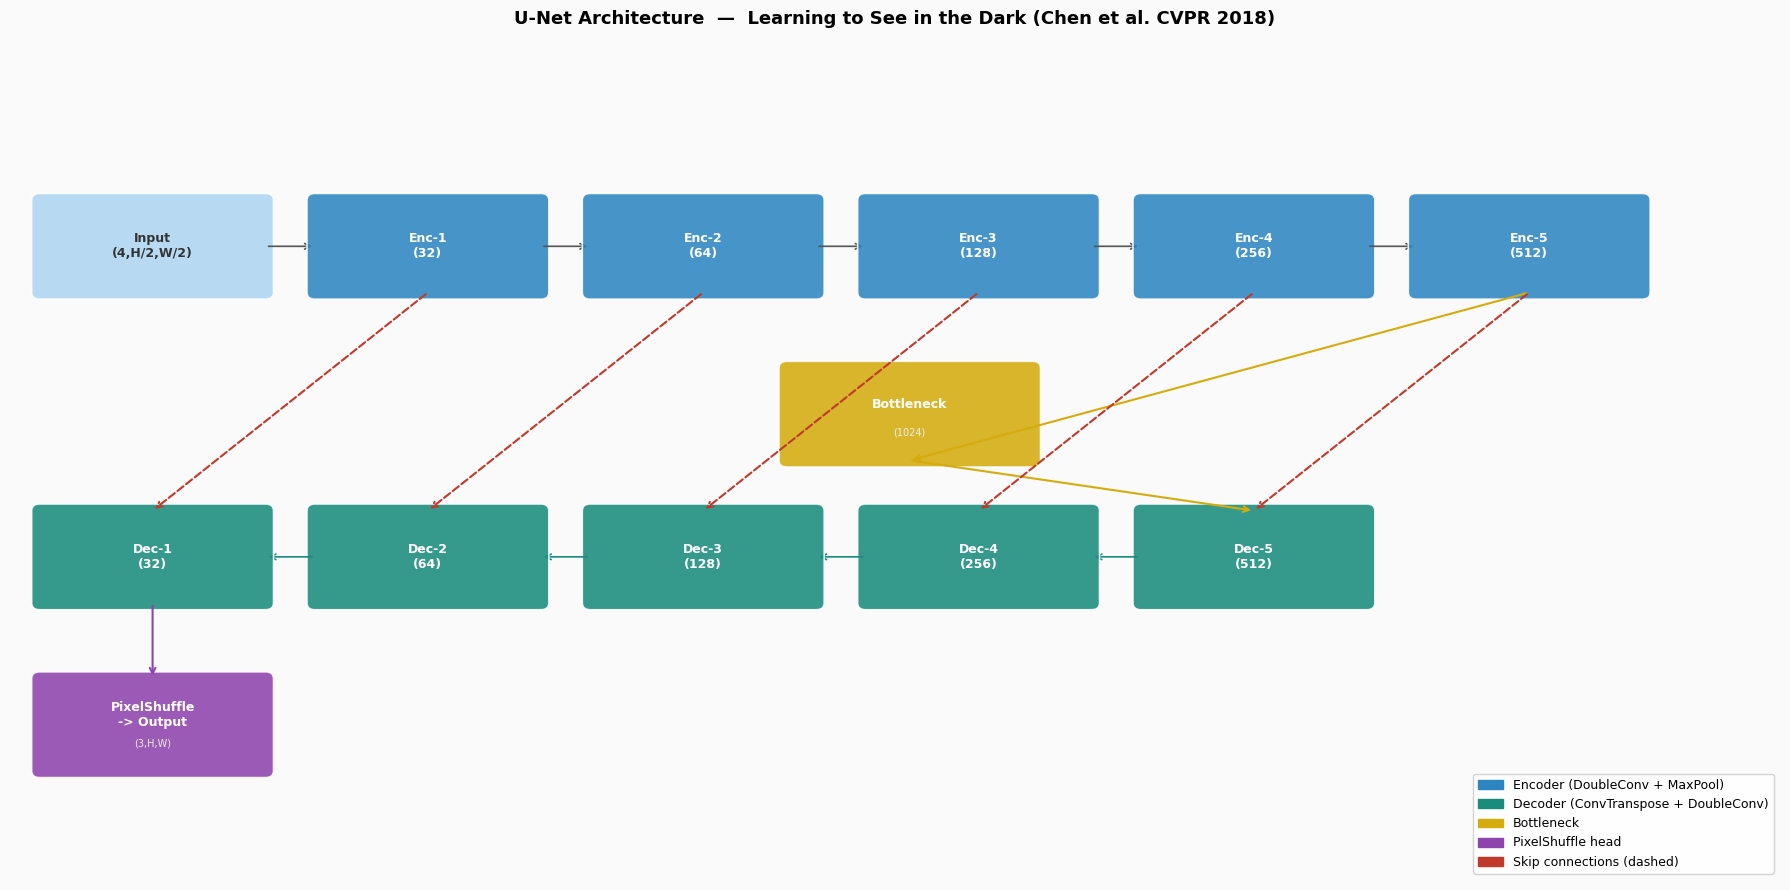

In [8]:
# ── 8a. U-Net Architecture Diagram ───────────────────────────────────────────
def vis_unet_architecture(save=True):
    fig, ax = plt.subplots(figsize=(18, 9))
    ax.set_xlim(0, 18); ax.set_ylim(0, 10); ax.axis('off')
    fig.patch.set_facecolor('#FAFAFA')

    BLUE='#2E86C1'; TEAL='#1A8C7D'; GOLD='#D4AC0D'; RED='#C0392B'

    def make_box(x, y, w, h, color, label, sublabel='', fs=9, tc='white'):
        r = mpatches.FancyBboxPatch((x,y), w, h,
                boxstyle='round,pad=0.08', lw=1.2,
                edgecolor='white', facecolor=color, alpha=0.88, zorder=3)
        ax.add_patch(r)
        ax.text(x+w/2, y+h/2+(0.12 if sublabel else 0), label,
                ha='center', va='center', fontsize=fs,
                fontweight='bold', color=tc, zorder=4)
        if sublabel:
            ax.text(x+w/2, y+h/2-0.22, sublabel, ha='center', va='center',
                    fontsize=7, color='#EEE', zorder=4)

    # Encoder
    enc_labels = ['Input\n(4,H/2,W/2)', 'Enc-1\n(32)', 'Enc-2\n(64)',
                  'Enc-3\n(128)', 'Enc-4\n(256)', 'Enc-5\n(512)']
    xs = [0.3 + i*2.8 for i in range(6)]
    for i, (label, color) in enumerate(zip(enc_labels, ['#AED6F1']+[BLUE]*5)):
        tc = '#333' if i==0 else 'white'
        make_box(xs[i], 7.0, 2.3, 1.1, color, label, tc=tc)
        if i < 5:
            ax.annotate('', xy=(xs[i+1], 7.55), xytext=(xs[i]+2.3, 7.55),
                        arrowprops=dict(arrowstyle='->', color='#555', lw=1.2))

    # Bottleneck
    make_box(7.9, 5.0, 2.5, 1.1, GOLD, 'Bottleneck', '(1024)', tc='white')
    ax.annotate('', xy=(9.15, 5.0), xytext=(xs[5]+1.15, 7.0),
                arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5))

    # Decoder
    dec_labels = ['Dec-5\n(512)','Dec-4\n(256)','Dec-3\n(128)','Dec-2\n(64)','Dec-1\n(32)']
    dec_xs = [xs[i] for i in range(4,-1,-1)]
    for i, (label, dx) in enumerate(zip(dec_labels, dec_xs)):
        make_box(dx, 3.3, 2.3, 1.1, TEAL, label)
        if i < 4:
            ax.annotate('', xy=(dec_xs[i+1]+2.3, 3.85), xytext=(dx, 3.85),
                        arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.2))

    ax.annotate('', xy=(dec_xs[0]+1.15, 4.4), xytext=(9.15, 5.0),
                arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5))

    # Skip connections
    for enc_i, dec_i in enumerate(range(4,-1,-1)):
        ax.annotate('', xy=(dec_xs[enc_i]+1.15, 4.4),
                    xytext=(xs[dec_i+1]+1.15, 7.0),
                    arrowprops=dict(arrowstyle='->', color=RED, lw=1.5,
                                   linestyle='dashed'))

    # Output head
    make_box(0.3, 1.3, 2.3, 1.1, '#8E44AD', 'PixelShuffle\n-> Output', '(3,H,W)')
    ax.annotate('', xy=(1.45, 2.4), xytext=(dec_xs[4]+1.15, 3.3),
                arrowprops=dict(arrowstyle='->', color='#8E44AD', lw=1.5))

    # Legend
    legend = [
        mpatches.Patch(color=BLUE,     label='Encoder (DoubleConv + MaxPool)'),
        mpatches.Patch(color=TEAL,     label='Decoder (ConvTranspose + DoubleConv)'),
        mpatches.Patch(color=GOLD,     label='Bottleneck'),
        mpatches.Patch(color='#8E44AD',label='PixelShuffle head'),
        mpatches.Patch(color=RED,      label='Skip connections (dashed)'),
    ]
    ax.legend(handles=legend, loc='lower right', fontsize=9, framealpha=0.85)
    ax.set_title('U-Net Architecture  —  Learning to See in the Dark (Chen et al. CVPR 2018)',
                 fontsize=13, fontweight='bold', pad=12)
    plt.tight_layout()
    if save:
        p = os.path.join(VIS_DIR, '01_unet_arch.png')
        plt.savefig(p, dpi=150, bbox_inches='tight')
        print(f'Saved -> {p}')
    plt.show()

vis_unet_architecture()

Saved -> /kaggle/working/visualizations/02_pixel_shuffle.png


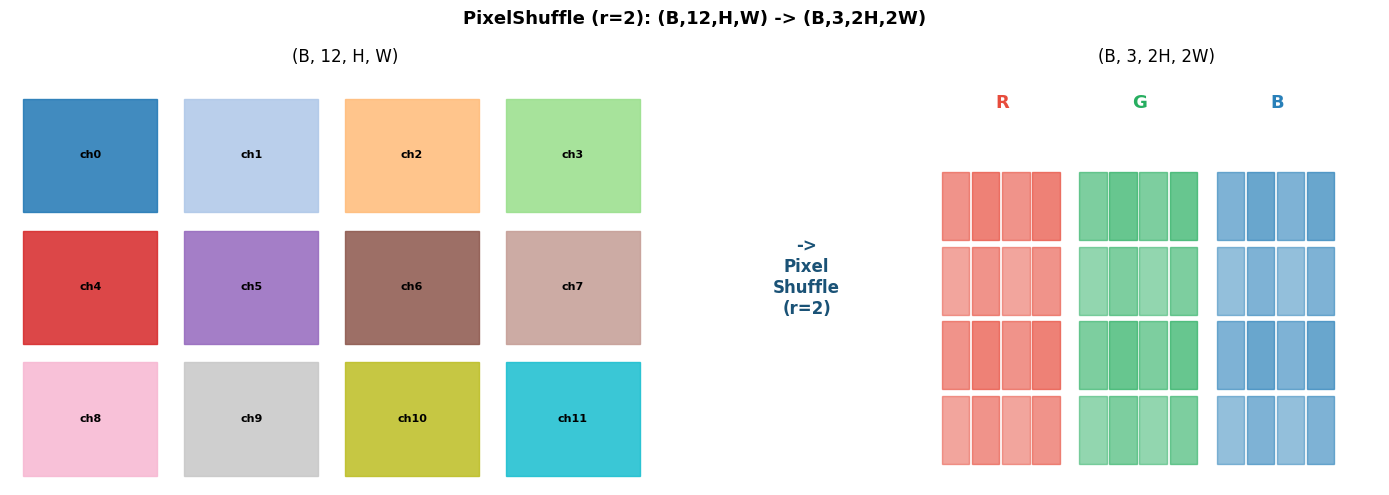

In [9]:
# ── 8b. PixelShuffle Diagram ──────────────────────────────────────────────────
def vis_pixel_shuffle(save=True):
    fig, axes = plt.subplots(1,3, figsize=(14,5),
                              gridspec_kw={'width_ratios':[3,1,2]})
    fig.suptitle('PixelShuffle (r=2): (B,12,H,W) -> (B,3,2H,2W)',
                 fontsize=13, fontweight='bold')

    # 12-channel schematic
    cmap = plt.cm.tab20
    for i in range(12):
        row, col = divmod(i,4)
        axes[0].add_patch(mpatches.Rectangle((col*1.2,(2-row)*1.4),1.0,1.2,
                           color=cmap(i/12), alpha=0.85))
        axes[0].text(col*1.2+0.5,(2-row)*1.4+0.6,f'ch{i}',
                    ha='center',va='center',fontsize=8,fontweight='bold')
    axes[0].set_xlim(-0.1,4.9); axes[0].set_ylim(-0.1,4.3)
    axes[0].set_title('(B, 12, H, W)'); axes[0].axis('off')

    axes[1].text(0.5,0.5,'->\nPixel\nShuffle\n(r=2)',
                ha='center',va='center',fontsize=12,
                fontweight='bold',color='#1A5276')
    axes[1].axis('off')

    # 3-channel 2x output schematic
    for c,(col,lab) in enumerate(zip(['#E74C3C','#27AE60','#2980B9'],['R','G','B'])):
        for r in range(4):
            for cc in range(4):
                axes[2].add_patch(mpatches.Rectangle((c*1.6+cc*0.35,r*0.35),
                                   0.32,0.32,color=col,alpha=0.5+0.1*(r%2+cc%2)))
        axes[2].text(c*1.6+0.7,4.5*0.35+0.1,lab,
                    ha='center',fontsize=13,fontweight='bold',color=col)
    axes[2].set_xlim(-0.1,5.1); axes[2].set_ylim(-0.1,1.85)
    axes[2].set_title('(B, 3, 2H, 2W)'); axes[2].axis('off')

    plt.tight_layout()
    if save:
        p = os.path.join(VIS_DIR,'02_pixel_shuffle.png')
        plt.savefig(p,dpi=150,bbox_inches='tight')
        print(f'Saved -> {p}')
    plt.show()

vis_pixel_shuffle()

Found sample RAW: /kaggle/input/datasets/moodoki/sid-sony/Sony/short/00037_01_0.04s.ARW
Saved -> /kaggle/working/visualizations/03_bayer_channels.png


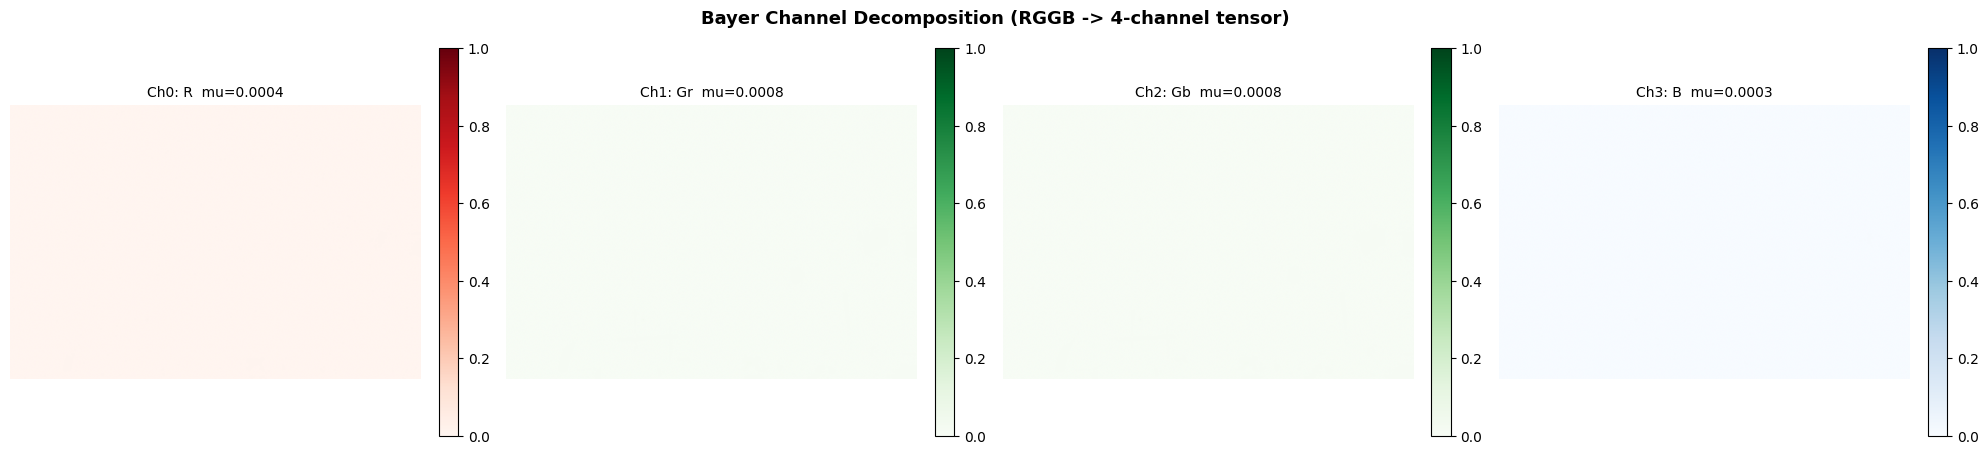

Saved -> /kaggle/working/visualizations/04_amplification.png


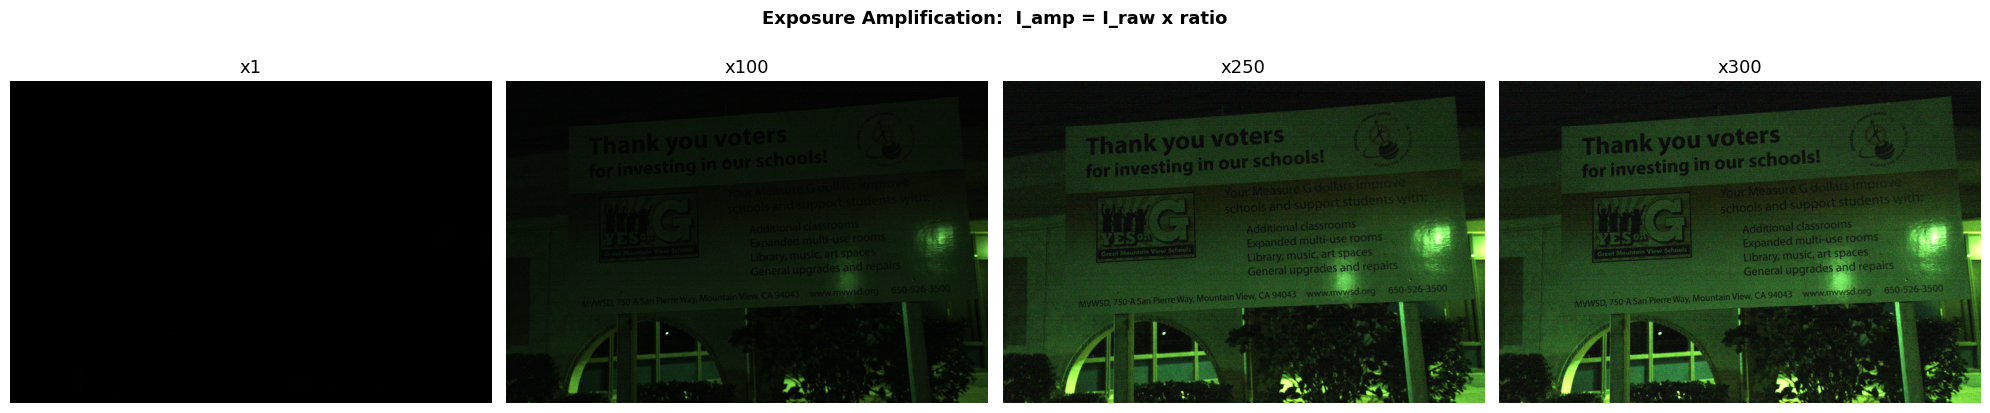

In [10]:
# ── 8c. Bayer channels & amplification — needs a sample .ARW ─────────────────
# Finds the first available .ARW in the dataset and visualizes it.

def vis_bayer_channels(raw_path, save=True):
    packed = pack_raw_sony(raw_path)
    fig, axes = plt.subplots(1,4, figsize=(20,4.5))
    fig.suptitle('Bayer Channel Decomposition (RGGB -> 4-channel tensor)',
                 fontsize=13, fontweight='bold')
    info = [('R',  'Reds'), ('Gr','Greens'), ('Gb','Greens'), ('B','Blues')]
    for i,(ax,(ch,cm)) in enumerate(zip(axes,info)):
        im = ax.imshow(packed[i], cmap=cm, vmin=0, vmax=1)
        ax.set_title(f'Ch{i}: {ch}  mu={packed[i].mean():.4f}', fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    if save:
        p = os.path.join(VIS_DIR,'03_bayer_channels.png')
        plt.savefig(p,dpi=150,bbox_inches='tight'); print(f'Saved -> {p}')
    plt.show()


def vis_amplification(raw_path, ratios=(1,100,250,300), save=True):
    packed    = pack_raw_sony(raw_path)
    rgb_proxy = np.transpose(packed[[0,1,3]], (1,2,0))
    n = len(ratios)
    fig, axes = plt.subplots(1,n, figsize=(5*n,4.5))
    fig.suptitle('Exposure Amplification:  I_amp = I_raw x ratio',
                 fontsize=13, fontweight='bold')
    for ax,r in zip(axes,ratios):
        ax.imshow(np.clip(rgb_proxy*r,0,1))
        ax.set_title(f'x{r}', fontsize=13); ax.axis('off')
    plt.tight_layout()
    if save:
        p = os.path.join(VIS_DIR,'04_amplification.png')
        plt.savefig(p,dpi=150,bbox_inches='tight'); print(f'Saved -> {p}')
    plt.show()


# Auto-find a sample RAW file
sample_arw = None
arw_search = glob.glob(os.path.join(SONY_SHORT_DIR, '*.ARW'))
if arw_search:
    sample_arw = arw_search[0]
    print(f'Found sample RAW: {sample_arw}')
    vis_bayer_channels(sample_arw)
    vis_amplification(sample_arw)
else:
    print('Dataset not found at expected path — skipping data visualizations.')
    print('Make sure to add dataset: + Add Data -> marcorosato/sid-dataset')

## Cell 9 — Training

⚠️ Requires SID dataset attached. Enable GPU before running.

  SIDSonyDataset [Sony_train_list.txt] — 400 pairs
  SIDSonyDataset [Sony_test_list.txt] — 200 pairs
Fresh training from epoch 0.
  build_criterion → SSIM phase (L1 + SSIM*0.02 + Perc*0.04)
Training epochs 1 → 200
  Ep 0001 | Batch 0000/0100 | Loss 0.388873 | Peak VRAM 3.3/15.6 GB
  Ep 0001 | Batch 0050/0100 | Loss 0.349243 | Peak VRAM 3.3/15.6 GB
Epoch 0001/200 [SSIM] | Loss 0.328037 | LR 1.00e-04 | 281.5s
  Ep 0002 | Batch 0000/0100 | Loss 0.274412 | Peak VRAM 1.4/15.6 GB
  Ep 0002 | Batch 0050/0100 | Loss 0.265725 | Peak VRAM 1.6/15.6 GB
Epoch 0002/200 [SSIM] | Loss 0.256320 | LR 2.00e-04 | 279.0s
  Ep 0003 | Batch 0000/0100 | Loss 0.251480 | Peak VRAM 1.4/15.6 GB
  Ep 0003 | Batch 0050/0100 | Loss 0.213946 | Peak VRAM 1.6/15.6 GB
Epoch 0003/200 [SSIM] | Loss 0.210975 | LR 3.00e-04 | 283.2s
  Ep 0004 | Batch 0000/0100 | Loss 0.296420 | Peak VRAM 1.4/15.6 GB
  Ep 0004 | Batch 0050/0100 | Loss 0.192456 | Peak VRAM 1.6/15.6 GB
Epoch 0004/200 [SSIM] | Loss 0.186403 | LR 3.00e-04 | 279.0

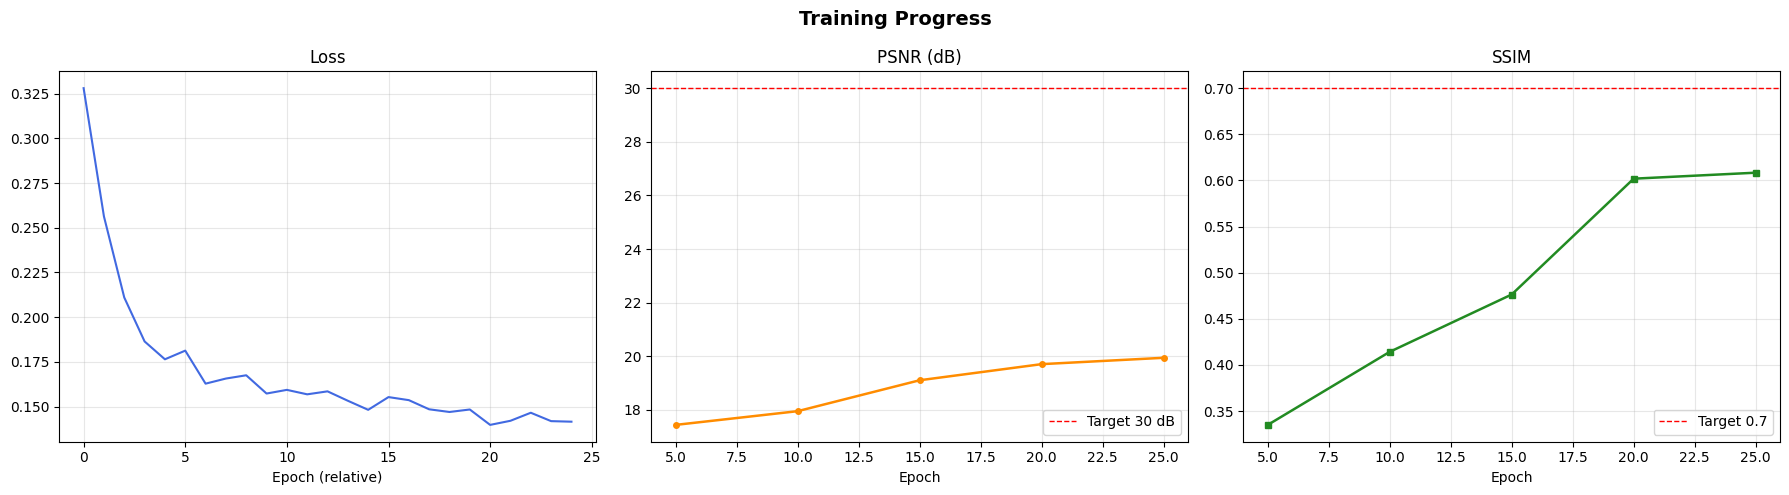

  Ep 0026 | Batch 0000/0100 | Loss 0.224232 | Peak VRAM 1.4/15.6 GB
  Ep 0026 | Batch 0050/0100 | Loss 0.143611 | Peak VRAM 1.6/15.6 GB
Epoch 0026/200 [SSIM] | Loss 0.140247 | LR 2.90e-04 | 279.3s
  Ep 0027 | Batch 0000/0100 | Loss 0.158535 | Peak VRAM 1.4/15.6 GB
  Ep 0027 | Batch 0050/0100 | Loss 0.135715 | Peak VRAM 1.6/15.6 GB
Epoch 0027/200 [SSIM] | Loss 0.136003 | LR 2.89e-04 | 303.4s
  Ep 0028 | Batch 0000/0100 | Loss 0.204622 | Peak VRAM 1.4/15.6 GB
  Ep 0028 | Batch 0050/0100 | Loss 0.133035 | Peak VRAM 1.6/15.6 GB
Epoch 0028/200 [SSIM] | Loss 0.130272 | LR 2.88e-04 | 295.7s
  Ep 0029 | Batch 0000/0100 | Loss 0.089351 | Peak VRAM 1.4/15.6 GB
  Ep 0029 | Batch 0050/0100 | Loss 0.127704 | Peak VRAM 1.6/15.6 GB
Epoch 0029/200 [SSIM] | Loss 0.130875 | LR 2.87e-04 | 289.5s
  Ep 0030 | Batch 0000/0100 | Loss 0.096285 | Peak VRAM 1.4/15.6 GB
  Ep 0030 | Batch 0050/0100 | Loss 0.129131 | Peak VRAM 1.6/15.6 GB
Epoch 0030/200 [SSIM] | Loss 0.128508 | LR 2.86e-04 | 292.5s
  >> Eval | PSN

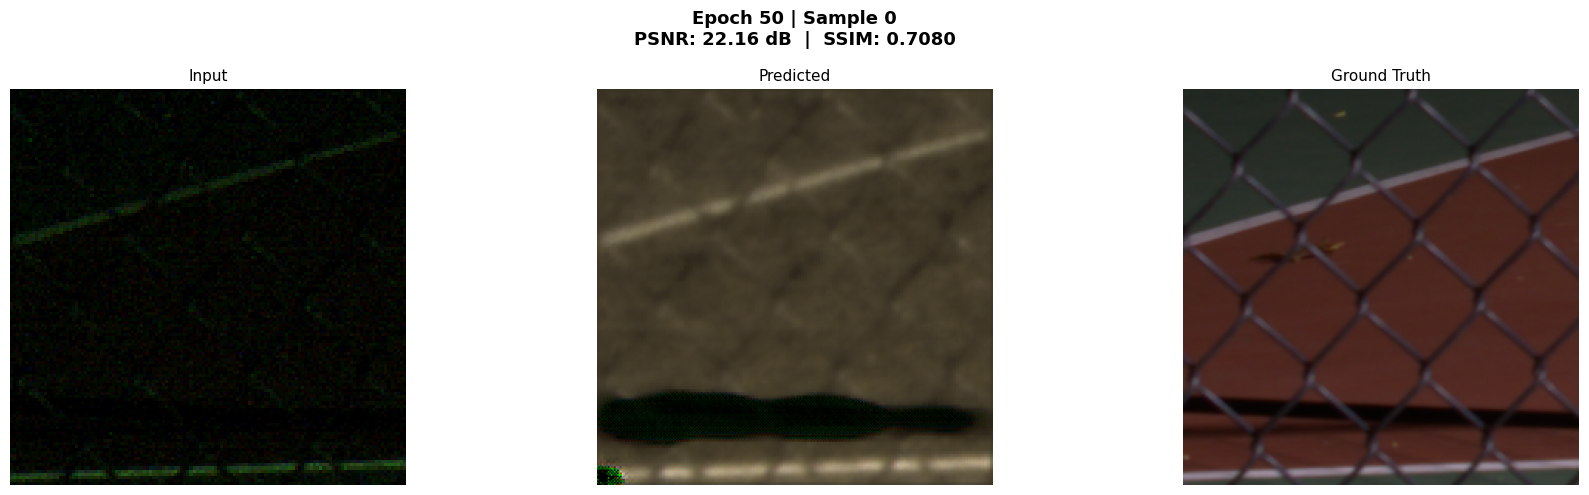

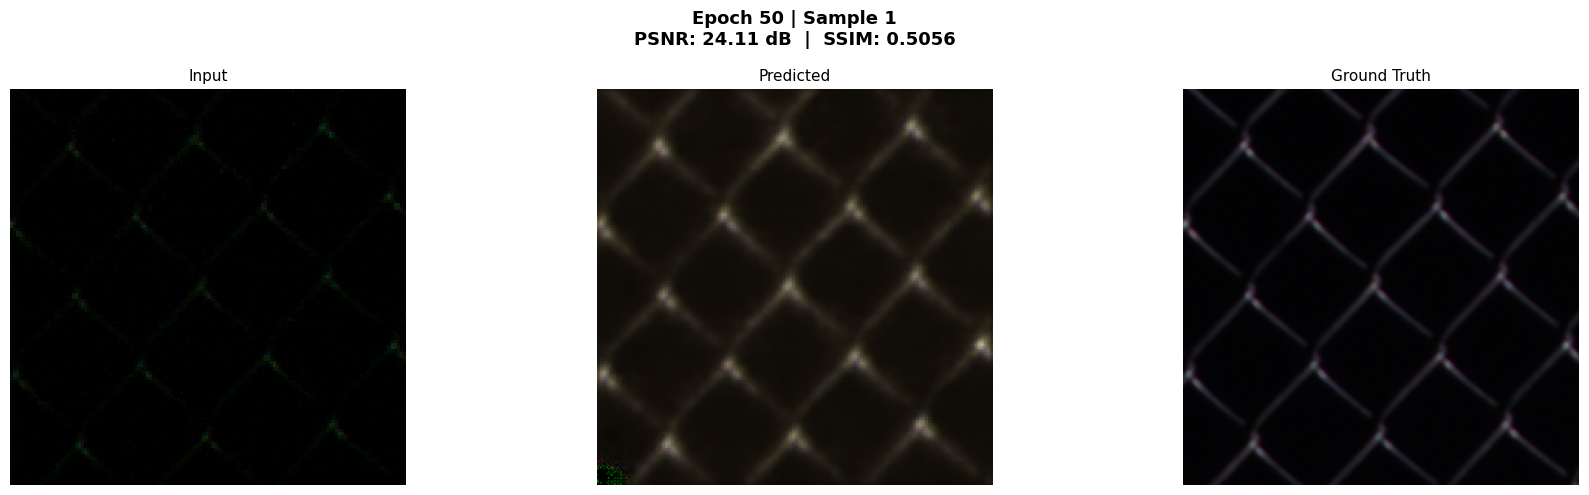

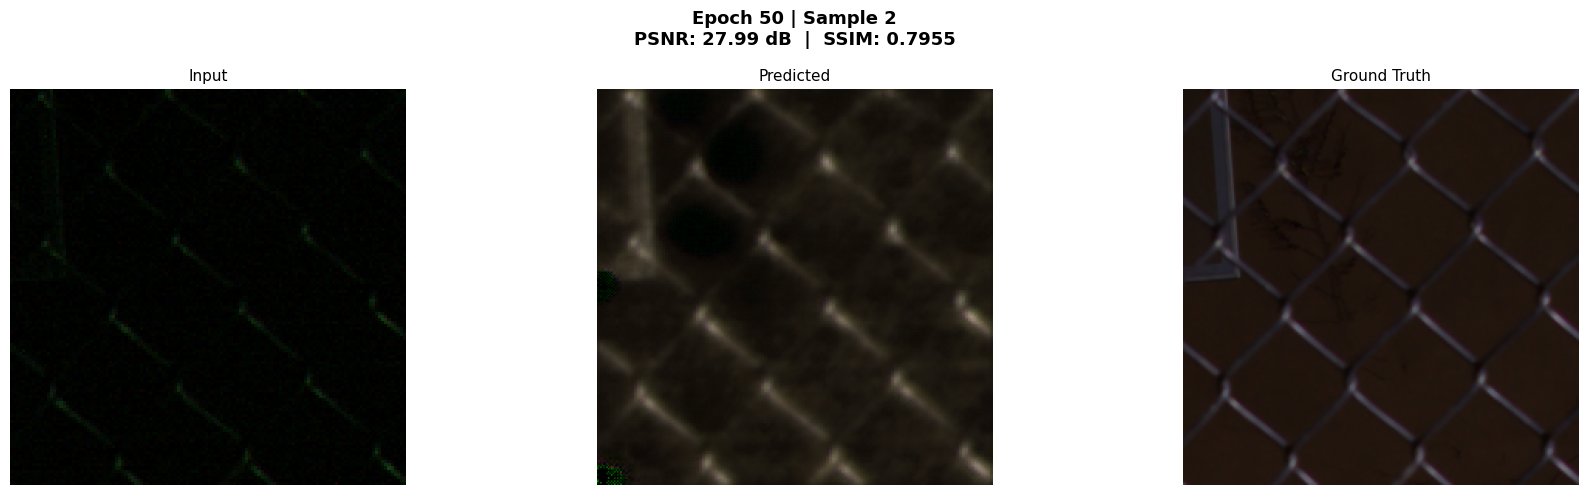

  >> Eval | PSNR 19.02 dB  SSIM 0.6566  (N=30)
  >> Checkpoint saved → /kaggle/working/checkpoints/ckpt_0050.pth


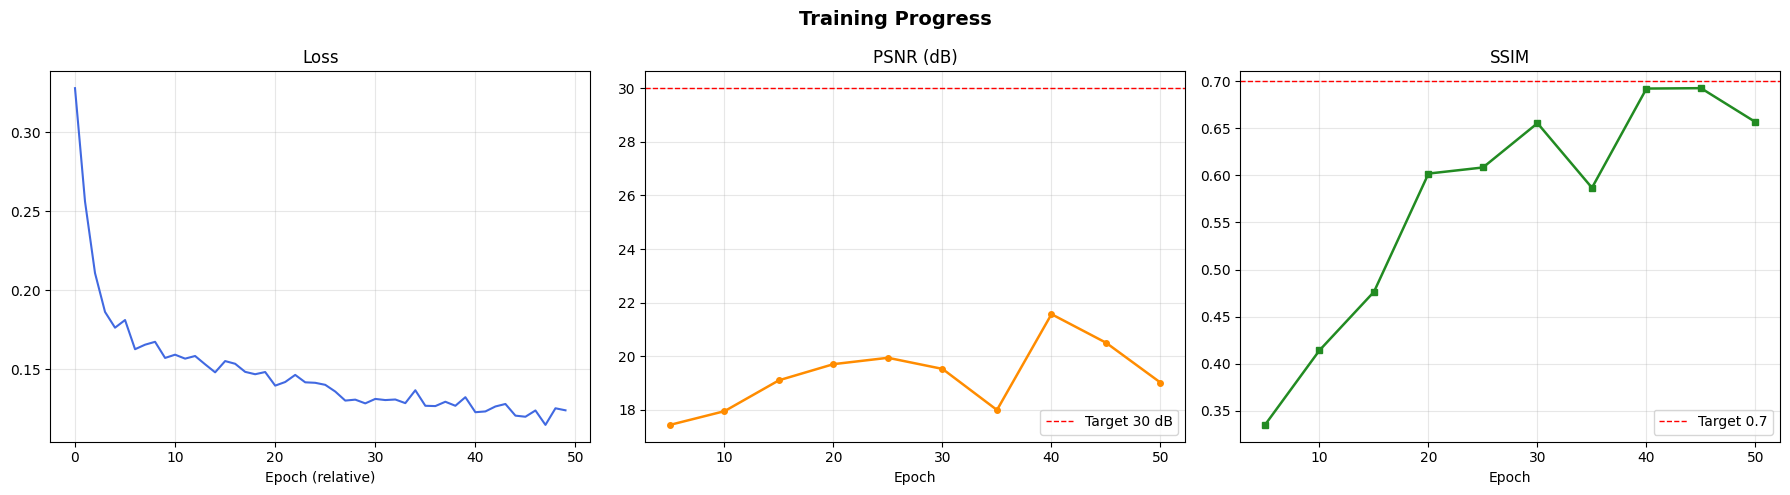

  Ep 0051 | Batch 0000/0100 | Loss 0.190244 | Peak VRAM 1.4/15.6 GB
  Ep 0051 | Batch 0050/0100 | Loss 0.113725 | Peak VRAM 1.6/15.6 GB
Epoch 0051/200 [SSIM] | Loss 0.123822 | LR 2.58e-04 | 285.5s
  Ep 0052 | Batch 0000/0100 | Loss 0.112692 | Peak VRAM 1.4/15.6 GB
  Ep 0052 | Batch 0050/0100 | Loss 0.118546 | Peak VRAM 1.6/15.6 GB
Epoch 0052/200 [SSIM] | Loss 0.117262 | LR 2.57e-04 | 281.1s
  Ep 0053 | Batch 0000/0100 | Loss 0.116557 | Peak VRAM 1.4/15.6 GB
  Ep 0053 | Batch 0050/0100 | Loss 0.114510 | Peak VRAM 1.6/15.6 GB
Epoch 0053/200 [SSIM] | Loss 0.115507 | LR 2.55e-04 | 281.1s
  Ep 0054 | Batch 0000/0100 | Loss 0.096962 | Peak VRAM 1.4/15.6 GB
  Ep 0054 | Batch 0050/0100 | Loss 0.112444 | Peak VRAM 1.6/15.6 GB


KeyboardInterrupt: 

In [13]:
# CELL 9 — Training  (full replacement)
# New vs original:
#   - Every periodic checkpoint (ckpt_NNNN.pth) and 'latest.pth' carry
#     optimizer / scheduler / scaler state + psnr_phase + history lists
#     so RESUME = True + RESUME_CKPT = any of those files gives an exact
#     continuation regardless of which phase was active.
#   - Phase switch: when eval SSIM ≥ SSIM_TARGET, criterion is rebuilt
#     (PSNR-focused weights), LR is reset, scheduler restarted.
#   - Dynamic eval cadence: EVAL_EVERY in SSIM phase, EVAL_EVERY_PSNR after.
#   - Checkpoint priority flips: best_ssim_model.pth during SSIM phase,
#     best_psnr_model.pth during PSNR phase.
# ══════════════════════════════════════════════════════════════════════════════
 
import os, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR
 
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'
torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True   # was False
torch.backends.cudnn.allow_tf32       = True   # was False
 
BATCH_SIZE_TRAIN  = BATCH_SIZE
ACCUM_STEPS       = 4
NUM_WORKERS_TRAIN = 2
 
 
# ── CUDA Prefetcher (unchanged) ───────────────────────────────────────────────
class CUDAPrefetcher:
    def __init__(self, dataloader, device):
        self.dataloader = dataloader
        self.device     = device
        self.stream     = torch.cuda.Stream()
        self._iter      = None
 
    def __len__(self):  return len(self.dataloader)
    def __iter__(self):
        self._iter = iter(self.dataloader)
        self._preload()
        return self
 
    def _preload(self):
        try:
            short, gt = next(self._iter)
        except StopIteration:
            self._next_short = self._next_gt = None
            return
        with torch.cuda.stream(self.stream):
            self._next_short = (short
                .to(self.device, non_blocking=True)
                .to(memory_format=torch.channels_last))
            self._next_gt = (gt
                .to(self.device, non_blocking=True)
                .to(memory_format=torch.channels_last))
 
    def __next__(self):
        torch.cuda.current_stream().wait_stream(self.stream)
        short, gt = self._next_short, self._next_gt
        if short is None:
            raise StopIteration
        short.record_stream(torch.cuda.current_stream())
        gt.record_stream(torch.cuda.current_stream())
        self._preload()
        return short, gt
 
 
# ── GPU Augmentation (unchanged) ─────────────────────────────────────────────
def gpu_augment(short: torch.Tensor, gt: torch.Tensor):
    B = short.size(0)
    mask = torch.rand(B, device=short.device) > 0.5
    if mask.any():
        short[mask] = short[mask].flip(-1);  gt[mask] = gt[mask].flip(-1)
    mask = torch.rand(B, device=short.device) > 0.5
    if mask.any():
        short[mask] = short[mask].flip(-2);  gt[mask] = gt[mask].flip(-2)
    mask = torch.rand(B, device=short.device) > 0.5
    if mask.any():
        short[mask] = short[mask].rot90(1, [-2, -1])
        gt[mask]    = gt[mask].rot90(1, [-2, -1])
    mask = torch.rand(B, device=short.device) > 0.5
    if mask.any():
        jitter = torch.empty(mask.sum(), 1, 1, 1, device=short.device).uniform_(0.8, 1.2)
        short[mask] = (short[mask] * jitter).clamp_(0, 1)
    mask = torch.rand(B, device=gt.device) > 0.5
    if mask.any():
        scale = torch.empty(mask.sum(), 3, 1, 1, device=gt.device).uniform_(0.95, 1.05)
        gt[mask] = (gt[mask] * scale).clamp_(0, 1)
    return short, gt
 
 
# ── Visualisation helpers (unchanged) ────────────────────────────────────────
def vis_comparison(short_raw, pred_rgb, gt_rgb, title='', save_name=None):
    def hwc(x): return np.transpose(x, (1,2,0)) if x.shape[0] in (3,4) else x
    raw_p = np.clip(hwc(short_raw[[0,1,3]]), 0, 1)
    pred  = np.clip(hwc(pred_rgb), 0, 1)
    gt    = np.clip(hwc(gt_rgb),   0, 1)
    psnr, ssim = compute_metrics(pred, gt)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{title}\nPSNR: {psnr:.2f} dB  |  SSIM: {ssim:.4f}',
                 fontsize=13, fontweight='bold')
    for ax, img, lbl in zip(axes, [raw_p, pred, gt],
            ['Input', 'Predicted', 'Ground Truth']):
        ax.imshow(img); ax.set_title(lbl, fontsize=11); ax.axis('off')
    plt.tight_layout()
    if save_name:
        plt.savefig(os.path.join(VIS_DIR, save_name), dpi=150, bbox_inches='tight')
    plt.show()
    return psnr, ssim
 
 
def vis_training_curves(losses, psnrs, ssims, start_epoch=0, psnr_phase_epoch=None, save=True):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Training Progress', fontsize=14, fontweight='bold')
 
    axes[0].plot(losses, color='royalblue', lw=1.5)
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch (relative)'); axes[0].grid(alpha=0.3)
 
    xp = [start_epoch + (i + 1) * EVAL_EVERY for i in range(len(psnrs))]
    axes[1].plot(xp, psnrs, color='darkorange', lw=1.8, marker='o', ms=4)
    axes[1].axhline(30, color='red', lw=1, linestyle='--', label='Target 30 dB')
    if psnr_phase_epoch:
        axes[1].axvline(psnr_phase_epoch, color='purple', lw=1.2, linestyle=':',
                        label=f'PSNR phase @ ep{psnr_phase_epoch}')
    axes[1].set_title('PSNR (dB)'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)
 
    axes[2].plot(xp, ssims, color='forestgreen', lw=1.8, marker='s', ms=4)
    axes[2].axhline(SSIM_TARGET, color='red', lw=1, linestyle='--',
                    label=f'Target {SSIM_TARGET}')
    if psnr_phase_epoch:
        axes[2].axvline(psnr_phase_epoch, color='purple', lw=1.2, linestyle=':',
                        label=f'PSNR phase @ ep{psnr_phase_epoch}')
    axes[2].set_title('SSIM'); axes[2].set_xlabel('Epoch')
    axes[2].legend(); axes[2].grid(alpha=0.3)
 
    plt.tight_layout()
    if save:
        plt.savefig(os.path.join(VIS_DIR, '05_training_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
 
 
# ── Checkpoint helpers ────────────────────────────────────────────────────────
def save_checkpoint(path, epoch, model, optimizer, scheduler, scaler,
                    psnr, ssim, psnr_phase, losses, psnrs, ssims,
                    best_psnr, best_ssim, psnr_phase_epoch):
    """Save a fully resumable checkpoint."""
    torch.save({
        'epoch':             epoch,
        'state_dict':        model.state_dict(),
        'optimizer':         optimizer.state_dict(),
        'scheduler':         scheduler.state_dict(),
        'scaler':            scaler.state_dict(),
        'psnr':              psnr,
        'ssim':              ssim,
        'psnr_phase':        psnr_phase,
        'psnr_phase_epoch':  psnr_phase_epoch,
        'losses':            losses,
        'psnrs':             psnrs,
        'ssims':             ssims,
        'best_psnr':         best_psnr,
        'best_ssim':         best_ssim,
    }, path)
 
 
def load_checkpoint(path, model, optimizer, scheduler, scaler, device):
    """
    Load a checkpoint.  Returns a dict of all stored state so the caller
    can restore every variable without guessing what was saved.
    """
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['state_dict'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    scaler.load_state_dict(ckpt['scaler'])
    print(f'  Loaded  : {path}')
    print(f'  Epoch   : {ckpt["epoch"]}')
    print(f'  PSNR    : {ckpt["psnr"]:.2f} dB   SSIM: {ckpt["ssim"]:.4f}')
    print(f'  Phase   : {"PSNR" if ckpt.get("psnr_phase") else "SSIM"}')
    return ckpt
 
 
# ── Training step ─────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, scaler, device,
                    epoch, warmup_epochs, warmup_start_epoch, lr_init):
    model.train()
    total = 0.0
    optimizer.zero_grad(set_to_none=True)
    torch.cuda.reset_peak_memory_stats(device)
 
    relative_epoch = epoch - warmup_start_epoch
    if relative_epoch <= warmup_epochs:
        warmup_lr = lr_init * max(relative_epoch, 1) / warmup_epochs
        for pg in optimizer.param_groups:
            pg['lr'] = warmup_lr
 
    prefetcher = CUDAPrefetcher(loader, device)
    for i, (short, gt) in enumerate(prefetcher):
        short, gt = gpu_augment(short, gt)
 
        with autocast(dtype=torch.float16):
            loss = criterion(model(short), gt)
            if ACCUM_STEPS > 1:
                loss = loss / ACCUM_STEPS
 
        scaler.scale(loss).backward()
 
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(loader):
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
 
        total += loss.item() * (ACCUM_STEPS if ACCUM_STEPS > 1 else 1)
 
        if i % 50 == 0:
            peak      = torch.cuda.max_memory_allocated(device) / 1e9
            total_mem = torch.cuda.get_device_properties(device).total_memory / 1e9
            print(f'  Ep {epoch:04d} | Batch {i:04d}/{len(loader):04d} '
                  f'| Loss {total/(i+1):.6f} '
                  f'| Peak VRAM {peak:.1f}/{total_mem:.1f} GB')
 
    return total / max(len(loader), 1)
 
 
@torch.no_grad()
def evaluate(model, loader, device, n=30, epoch=0, save_imgs=False):
    model.eval()
    psnrs, ssims = [], []
    prefetcher = CUDAPrefetcher(loader, device)
    for i, (short, gt_dev) in enumerate(prefetcher):
        if i >= n: break
        with autocast(dtype=torch.float16):
            pred = model(short)[0].cpu().float().numpy()
        gt_np = gt_dev[0].cpu().numpy()
        p, s  = compute_metrics(pred.transpose(1,2,0), gt_np.transpose(1,2,0))
        psnrs.append(p); ssims.append(s)
        if save_imgs and i < 3:
            vis_comparison(short[0].cpu().numpy(), pred, gt_np,
                           title=f'Epoch {epoch} | Sample {i}',
                           save_name=f'eval_ep{epoch:04d}_s{i}.png')
    mp, ms = float(np.mean(psnrs)), float(np.mean(ssims))
    print(f'  >> Eval | PSNR {mp:.2f} dB  SSIM {ms:.4f}  (N={len(psnrs)})')
    return mp, ms
 
 
# ── Dataloaders ───────────────────────────────────────────────────────────────
train_ds = SIDSonyDataset(TRAIN_LIST, SONY_SHORT_DIR, SONY_LONG_DIR,
                           PATCH_SIZE, augment=True,  max_pairs=MAX_TRAIN_PAIRS)
test_ds  = SIDSonyDataset(TEST_LIST,  SONY_SHORT_DIR, SONY_LONG_DIR,
                           PATCH_SIZE, augment=False, max_pairs=MAX_TEST_PAIRS)
train_ld = DataLoader(train_ds, BATCH_SIZE_TRAIN, shuffle=True,
                      num_workers=NUM_WORKERS_TRAIN, pin_memory=True,
                      persistent_workers=True, prefetch_factor=4, drop_last=True)
test_ld  = DataLoader(test_ds, 1, shuffle=False,
                      num_workers=NUM_WORKERS_TRAIN, pin_memory=True,
                      persistent_workers=True)
 
# ── Model ─────────────────────────────────────────────────────────────────────
model = UNet(4, BASE_CHANNELS, UNET_DEPTH).to(DEVICE)
model = model.to(memory_format=torch.channels_last)
 
# ── Initialise training state (overwritten by resume below) ───────────────────
psnr_phase        = False
psnr_phase_epoch  = None   # epoch at which the switch happened (for plot marker)
start_epoch       = 0
best_ssim         = 0.0
best_psnr         = 0.0
losses, psnrs, ssims = [], [], []
last_psnr, last_ssim = 0.0, 0.0
 
optimizer = optim.AdamW(model.parameters(), lr=LR_INIT, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - 3, eta_min=LR_FINAL)
scaler    = GradScaler()
 
# ── Resume ────────────────────────────────────────────────────────────────────
if RESUME:
    if not os.path.exists(RESUME_CKPT):
        raise FileNotFoundError(f'Checkpoint not found: {RESUME_CKPT}')
 
    ckpt = load_checkpoint(RESUME_CKPT, model, optimizer, scheduler, scaler, DEVICE)
 
    start_epoch      = ckpt['epoch']
    best_ssim        = ckpt.get('best_ssim',        ckpt.get('ssim', 0.0))
    best_psnr        = ckpt.get('best_psnr',        ckpt.get('psnr', 0.0))
    psnr_phase       = ckpt.get('psnr_phase',       False)
    psnr_phase_epoch = ckpt.get('psnr_phase_epoch', None)
    losses           = ckpt.get('losses',            [])
    psnrs            = ckpt.get('psnrs',             [])
    ssims            = ckpt.get('ssims',             [])
    last_psnr        = ckpt.get('psnr',             0.0)
    last_ssim        = ckpt.get('ssim',             0.0)
 
    # If the checkpoint was saved mid-PSNR-phase, the scheduler/optimizer
    # states are already correct (restored above).  Just rebuild the criterion.
    print(f'\nResuming from epoch {start_epoch} in '
          f'{"PSNR" if psnr_phase else "SSIM"} phase.')
else:
    print('Fresh training from epoch 0.')
 
criterion  = build_criterion(psnr_phase, DEVICE)
warmup_start   = start_epoch
warmup_lr_init = optimizer.param_groups[0]['lr']
 
print('=' * 60)
print(f'Training epochs {start_epoch+1} → {NUM_EPOCHS}')
print('=' * 60)
 
# ── Training loop ─────────────────────────────────────────────────────────────
for epoch in range(start_epoch + 1, NUM_EPOCHS + 1):
    t0   = time.time()
    loss = train_one_epoch(model, train_ld, criterion, optimizer, scaler,
                           DEVICE, epoch,
                           warmup_epochs=3,
                           warmup_start_epoch=warmup_start,
                           lr_init=warmup_lr_init)
 
    if (epoch - warmup_start) > 3:
        scheduler.step()
 
    losses.append(loss)
    lr = optimizer.param_groups[0]['lr']
    phase_tag = '[PSNR]' if psnr_phase else '[SSIM]'
    print(f'Epoch {epoch:04d}/{NUM_EPOCHS} {phase_tag} '
          f'| Loss {loss:.6f} | LR {lr:.2e} | {time.time()-t0:.1f}s')
 
    # ── Dynamic eval cadence ──────────────────────────────────────────────────
    eval_interval = EVAL_EVERY_PSNR if psnr_phase else EVAL_EVERY
    if epoch % eval_interval == 0:
        save_imgs = (epoch % 50 == 0)
        p, s = evaluate(model, test_ld, DEVICE, NUM_EVAL_SAMPLES, epoch, save_imgs)
        psnrs.append(p); ssims.append(s)
        last_psnr, last_ssim = p, s
 
        # ── Phase switch ──────────────────────────────────────────────────────
        if not psnr_phase and s >= SSIM_TARGET:
            psnr_phase       = True
            psnr_phase_epoch = epoch
            print(f'\n{"="*60}')
            print(f'  >> SSIM {s:.4f} ≥ {SSIM_TARGET} — switching to PSNR phase!')
            print(f'{"="*60}\n')
 
            criterion = build_criterion(psnr_phase, DEVICE)
 
            # Reset LR and scheduler for PSNR phase
            for pg in optimizer.param_groups:
                pg['lr'] = LR_PSNR_PHASE
            remaining = max(NUM_EPOCHS - epoch, 1)
            scheduler = CosineAnnealingLR(optimizer, T_max=remaining, eta_min=1e-6)
            warmup_start   = epoch          # suppress warmup for this phase
            warmup_lr_init = LR_PSNR_PHASE
            print(f'  LR reset to {LR_PSNR_PHASE:.1e} | '
                  f'New cosine schedule over {remaining} epochs')
 
        # ── Best-checkpoint logic (priority flips with phase) ─────────────────
        if psnr_phase:
            # PSNR phase: track best PSNR; only save SSIM if it also improves
            if p > best_psnr:
                best_psnr = p
                save_checkpoint(
                    os.path.join(CKPT_DIR, 'best_psnr_model.pth'),
                    epoch, model, optimizer, scheduler, scaler,
                    p, s, psnr_phase, losses, psnrs, ssims,
                    best_psnr, best_ssim, psnr_phase_epoch)
                print(f'  >> Best PSNR saved  PSNR={p:.2f} dB  SSIM={s:.4f}')
            if s > best_ssim:
                best_ssim = s   # update watermark but don't re-save ssim ckpt
        else:
            # SSIM phase: track best SSIM; also keep best PSNR checkpoint
            if s > best_ssim:
                best_ssim = s
                save_checkpoint(
                    os.path.join(CKPT_DIR, 'best_ssim_model.pth'),
                    epoch, model, optimizer, scheduler, scaler,
                    p, s, psnr_phase, losses, psnrs, ssims,
                    best_psnr, best_ssim, psnr_phase_epoch)
                print(f'  >> Best SSIM saved  SSIM={s:.4f}  PSNR={p:.2f} dB')
            if p > best_psnr:
                best_psnr = p
                save_checkpoint(
                    os.path.join(CKPT_DIR, 'best_psnr_model.pth'),
                    epoch, model, optimizer, scheduler, scaler,
                    p, s, psnr_phase, losses, psnrs, ssims,
                    best_psnr, best_ssim, psnr_phase_epoch)
                print(f'  >> Best PSNR saved  PSNR={p:.2f} dB  SSIM={s:.4f}')
 
    # ── Periodic checkpoint (always resumable) ────────────────────────────────
    if epoch % SAVE_EVERY == 0:
        periodic_path = os.path.join(CKPT_DIR, f'ckpt_{epoch:04d}.pth')
        save_checkpoint(
            periodic_path,
            epoch, model, optimizer, scheduler, scaler,
            last_psnr, last_ssim, psnr_phase, losses, psnrs, ssims,
            best_psnr, best_ssim, psnr_phase_epoch)
        # Overwrite 'latest.pth' as a convenience alias
        save_checkpoint(
            os.path.join(CKPT_DIR, 'latest.pth'),
            epoch, model, optimizer, scheduler, scaler,
            last_psnr, last_ssim, psnr_phase, losses, psnrs, ssims,
            best_psnr, best_ssim, psnr_phase_epoch)
        print(f'  >> Checkpoint saved → {periodic_path}')
        vis_training_curves(losses, psnrs, ssims,
                            start_epoch=start_epoch,
                            psnr_phase_epoch=psnr_phase_epoch)
 
phase_label = 'PSNR' if psnr_phase else 'SSIM'
print(f'\nDone.  Final phase: {phase_label}')
print(f'Best PSNR : {best_psnr:.2f} dB')
print(f'Best SSIM : {best_ssim:.4f}')
vis_training_curves(losses, psnrs, ssims,
                    start_epoch=start_epoch,
                    psnr_phase_epoch=psnr_phase_epoch)

## Cell 10 — Ablation Studies

**A** — L1 vs L1+Perceptual loss  
**B** — U-Net depth 3 vs 5

In [20]:
def run_ablation(label, use_perceptual, unet_depth, n_epochs=3, max_pairs=100):
    """Train a mini model and return (losses, psnrs) for ablation comparison."""
    import copy
    ds     = SIDSonyDataset(TRAIN_LIST, SONY_SHORT_DIR, SONY_LONG_DIR,
                             patch_size=256, augment=True, max_pairs=max_pairs)
    loader = DataLoader(ds, 1, shuffle=True, num_workers=2, pin_memory=True)
    val_ds     = SIDSonyDataset(TEST_LIST, SONY_SHORT_DIR, SONY_LONG_DIR,
                                 patch_size=256, augment=False, max_pairs=20)
    val_loader = DataLoader(val_ds, 1, shuffle=False, num_workers=2, pin_memory=True)

    model     = UNet(4, BASE_CHANNELS, unet_depth).to(DEVICE)
    criterion = SIDLoss(use_perceptual, PERCEPTUAL_WEIGHT, DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR_INIT)
    scaler    = GradScaler()

    losses, psnrs = [], []
    for epoch in range(1, n_epochs + 1):
        model.train()
        total = 0.0
        for short, gt in loader:
            short = short.to(DEVICE, non_blocking=True)
            gt    = gt.to(DEVICE,    non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast(dtype=torch.float16):
                loss = criterion(model(short), gt)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
            total += loss.item()
        losses.append(total / len(loader))

        p, s = evaluate(model, val_loader, DEVICE, n=10, epoch=epoch, save_imgs=False)
        psnrs.append(p)
        print(f'  [{label}] Epoch {epoch}/{n_epochs} | Loss {losses[-1]:.4f} | PSNR {p:.2f} dB')

    del model, criterion, optimizer, scaler
    torch.cuda.empty_cache()
    return losses, psnrs


print('Running Ablation A: L1  vs  L1 + Perceptual ...')
losses_l1,   psnrs_l1   = run_ablation('L1 only',       use_perceptual=False, unet_depth=UNET_DEPTH)
losses_perc, psnrs_perc = run_ablation('L1+Perceptual', use_perceptual=True,  unet_depth=UNET_DEPTH)

print('Running Ablation B: UNet depth 3  vs  depth 5 ...')
losses_d3, psnrs_d3 = run_ablation('Depth 3', use_perceptual=False, unet_depth=3)
losses_d5, psnrs_d5 = run_ablation('Depth 5', use_perceptual=False, unet_depth=5)

# ── Plot results ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Ablation Studies', fontsize=14, fontweight='bold')

epochs = list(range(1, len(losses_l1) + 1))

axes[0,0].plot(epochs, losses_l1,   label='L1 only',       color='royalblue')
axes[0,0].plot(epochs, losses_perc, label='L1+Perceptual', color='darkorange')
axes[0,0].set_title('A: Loss — L1 vs L1+Perceptual'); axes[0,0].set_xlabel('Epoch')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(epochs, psnrs_l1,   label='L1 only',       color='royalblue')
axes[0,1].plot(epochs, psnrs_perc, label='L1+Perceptual', color='darkorange')
axes[0,1].set_title('A: PSNR — L1 vs L1+Perceptual'); axes[0,1].set_xlabel('Epoch')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(epochs, losses_d3, label='Depth 3', color='forestgreen')
axes[1,0].plot(epochs, losses_d5, label='Depth 5', color='crimson')
axes[1,0].set_title('B: Loss — UNet Depth 3 vs 5'); axes[1,0].set_xlabel('Epoch')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(epochs, psnrs_d3, label='Depth 3', color='forestgreen')
axes[1,1].plot(epochs, psnrs_d5, label='Depth 5', color='crimson')
axes[1,1].set_title('B: PSNR — UNet Depth 3 vs 5'); axes[1,1].set_xlabel('Epoch')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
p = os.path.join(VIS_DIR, '06_ablation.png')
plt.savefig(p, dpi=150, bbox_inches='tight'); print(f'Saved -> {p}')
plt.show()


Running Ablation A: L1  vs  L1 + Perceptual ...
  SIDSonyDataset [Sony_train_list.txt] — 100 pairs
  SIDSonyDataset [Sony_test_list.txt] — 20 pairs


KeyboardInterrupt: 

## Cell 11 — Full Evaluation & Inference

Load best checkpoint → evaluate on entire test set → histogram + demo.

In [19]:
@torch.no_grad()
def full_evaluation(model):
    print('── Full Test-Set Evaluation ─────────────────────────────')
    ds     = SIDSonyDataset(TEST_LIST, SONY_SHORT_DIR, SONY_LONG_DIR, PATCH_SIZE, False, max_pairs=MAX_TEST_PAIRS)
    loader = DataLoader(ds, 1, shuffle=False, num_workers=2, pin_memory=True)

    model.eval()
    all_psnrs, all_ssims = [], []

    for i, (short, gt) in enumerate(tqdm(loader, desc='Evaluating')):
        short_dev = short.to(DEVICE, non_blocking=True)
        with autocast(dtype=torch.float16):
            pred = model(short_dev)[0].cpu().float().numpy()
        gt_np = gt[0].numpy()
        p, s  = compute_metrics(pred.transpose(1,2,0), gt_np.transpose(1,2,0))
        all_psnrs.append(p); all_ssims.append(s)

        # Save first 5 comparison images
        if i < 5:
            vis_comparison(short[0].cpu().numpy(), pred, gt_np,
                           title=f'Test Sample {i}',
                           save_name=f'final_sample_{i:03d}.png')

    mean_psnr = float(np.mean(all_psnrs))
    mean_ssim = float(np.mean(all_ssims))
    print(f'Mean PSNR : {mean_psnr:.2f} dB')
    print(f'  Mean SSIM : {mean_ssim:.4f}')
    print(f'  Samples   : {len(all_psnrs)}')

    # ── PSNR histogram ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Full Evaluation — PSNR {mean_psnr:.2f} dB  |  SSIM {mean_ssim:.4f}',
                 fontsize=13, fontweight='bold')
    axes[0].hist(all_psnrs, bins=20, color='darkorange', edgecolor='white', alpha=0.85)
    axes[0].axvline(mean_psnr, color='crimson', lw=2, linestyle='--', label=f'Mean {mean_psnr:.2f} dB')
    axes[0].set_title('PSNR Distribution'); axes[0].set_xlabel('PSNR (dB)')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].hist(all_ssims, bins=20, color='forestgreen', edgecolor='white', alpha=0.85)
    axes[1].axvline(mean_ssim, color='crimson', lw=2, linestyle='--', label=f'Mean {mean_ssim:.4f}')
    axes[1].set_title('SSIM Distribution'); axes[1].set_xlabel('SSIM')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    p = os.path.join(VIS_DIR, '07_full_eval_histograms.png')
    plt.savefig(p, dpi=150, bbox_inches='tight'); print(f'Saved -> {p}')
    plt.show()

    return all_psnrs, all_ssims


# ── Load best checkpoint and evaluate ─────────────────────────────────────────
ckpt_path = os.path.join(CKPT_DIR, 'best_model.pth')
if os.path.exists(ckpt_path):
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    eval_model = UNet(4, BASE_CHANNELS, UNET_DEPTH).to(DEVICE)
    eval_model.load_state_dict(ckpt['state_dict'])
    print(f'Loaded checkpoint from epoch {ckpt["epoch"]}  (PSNR {ckpt["psnr"]:.2f} dB)')
    all_psnrs, all_ssims = full_evaluation(eval_model)
else:
    print(f'No checkpoint found at {ckpt_path} — run training first.')


No checkpoint found at /kaggle/working/checkpoints/best_model.pth — run training first.
